In [1]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, ViTModel
device = "cuda" if torch.cuda.is_available() else "cpu"
repo_id = "facebook/dino-vitb16"
processor = AutoImageProcessor.from_pretrained(repo_id)
model = ViTModel.from_pretrained(repo_id, use_safetensors=True)  
model = model.to(device).eval()

print("device:", device)
print("hidden_size:", model.config.hidden_size)
print("num_hidden_layers:", model.config.num_hidden_layers)
print("image_size(config):", getattr(model.config, "image_size", None))
print("patch_size:", model.config.patch_size)
print("num_register_tokens:", getattr(model.config, "num_register_tokens", None))

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/dino-vitb16
Key                 | Status  | 
--------------------+---------+-
pooler.dense.weight | MISSING | 
pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device: cuda
hidden_size: 768
num_hidden_layers: 12
image_size(config): 224
patch_size: 16
num_register_tokens: None


In [2]:
# load images
import os
datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)
# load matlab mat file
from scipy.io import loadmat
img_mat = loadmat(filepath)
img = img_mat['img'].astype(np.float32)
images_gray = np.transpose(img, (2, 0, 1))
print('img:', images_gray.shape, images_gray.min(), images_gray.max())
print("num images:", len(images_gray))
# each 4 images belong to the same category
img_class = np.repeat(np.arange(len(images_gray) // 4), 4)
print("img_class:", img_class)

img: (32, 150, 600) 0.0 255.0
num images: 32
img_class: [0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5 6 6 6 6 7 7 7 7]


In [3]:
images_rgb = []
for i in range(len(images_gray)):
    im = images_gray[i]

    im = Image.fromarray(im.astype(np.uint8))
    if im.size != (256, 64):
        im = im.resize((256, 64), resample=Image.BICUBIC)
    im = im.convert("RGB")

    images_rgb.append(im)

print("prepared images_rgb:", len(images_rgb))

prepared images_rgb: 32


In [4]:
with torch.no_grad():
    inputs = processor(
        images=images_rgb,
        return_tensors="pt",
        do_resize=False,
        do_center_crop=False
    )
    # inputs typically has pixel_values: (B,3,H,W)
    for k, v in inputs.items():
        print(k, v.shape, v.dtype)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs, output_hidden_states=True, interpolate_pos_encoding=True)
    hidden_states = outputs.hidden_states

print("len(hidden_states) =", len(hidden_states), "(= embedding + num_layers)")
print("layer0 shape:", hidden_states[0].shape)
print("last layer shape:", hidden_states[-1].shape)

pixel_values torch.Size([32, 3, 64, 256]) torch.float32


len(hidden_states) = 13 (= embedding + num_layers)
layer0 shape: torch.Size([32, 65, 768])
last layer shape: torch.Size([32, 65, 768])


In [5]:
# check the range of hidden states for each layer
for li in range(len(hidden_states)):
    hs = hidden_states[li]  # (B, seq_len, dim)
    print(f"Layer {li}: shape={hs.shape}, min={hs.min().item():.4f}, max={hs.max().item():.4f}")

Layer 0: shape=torch.Size([32, 65, 768]), min=-4.7347, max=10.7933
Layer 1: shape=torch.Size([32, 65, 768]), min=-10.8397, max=8.2303
Layer 2: shape=torch.Size([32, 65, 768]), min=-10.4620, max=2.9999
Layer 3: shape=torch.Size([32, 65, 768]), min=-10.4210, max=4.1209
Layer 4: shape=torch.Size([32, 65, 768]), min=-10.4140, max=4.9726
Layer 5: shape=torch.Size([32, 65, 768]), min=-10.0750, max=4.2540
Layer 6: shape=torch.Size([32, 65, 768]), min=-10.9193, max=4.0212
Layer 7: shape=torch.Size([32, 65, 768]), min=-12.5102, max=3.8141
Layer 8: shape=torch.Size([32, 65, 768]), min=-11.3682, max=3.7518
Layer 9: shape=torch.Size([32, 65, 768]), min=-8.8473, max=4.0447
Layer 10: shape=torch.Size([32, 65, 768]), min=-7.1278, max=4.6794
Layer 11: shape=torch.Size([32, 65, 768]), min=-7.4579, max=7.1944
Layer 12: shape=torch.Size([32, 65, 768]), min=-7.2510, max=10.3738


In [6]:
# save the hidden states as array with shape (num_layers, B, seq_len, dim)
hidden_states_array = torch.stack(hidden_states, dim=0).cpu().numpy()
print("hidden_states_array shape:", hidden_states_array.shape)
np.save("outputs/dino_v1_vit_hidden_states.npy", hidden_states_array)

# zscore the patch tokens across sequence dimension
mean_all = hidden_states_array.mean(axis=-1, keepdims=True)
std_all = hidden_states_array.std(axis=-1, keepdims=True)
hidden_states_array_zscore = (hidden_states_array - mean_all) / (std_all + 1e-6)
# check the range of zscored hidden states for each layer
mean_zscore = hidden_states_array_zscore.mean(axis=-1)
std_zscore = hidden_states_array_zscore.std(axis=-1)
print("mean_zscore shape:", mean_zscore.shape, mean_zscore.min(), mean_zscore.max())
print("std_zscore shape:", std_zscore.shape, std_zscore.min(), std_zscore.max())

hidden_states_array shape: (13, 32, 65, 768)
mean_zscore shape: (13, 32, 65) -8.692344e-08 8.319815e-08
std_zscore shape: (13, 32, 65) 0.9999639 0.9999989


In [7]:
# pool the patch tokens by mean across sequence dimension (excluding cls token)
n_reg = getattr(model.config, 'num_register_tokens', 0)
patch_start = 1 + n_reg
patch_tokens = hidden_states_array_zscore[:, :, patch_start:, :]  # (num_layers, B, num_patches, dim)
pooled_patch_tokens = patch_tokens.mean(axis=2)
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)

# cls token is the first token in the sequence
cls_tokens = hidden_states_array_zscore[:, :, 0, :]  # (num_layers, B, dim)
print("cls_tokens shape:", cls_tokens.shape)

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)


In [8]:
# save the pooled patch tokens and cls tokens
np.save("outputs/dino_v1_vit_pooled_patch_tokens.npy", pooled_patch_tokens)
np.save("outputs/dino_v1_vit_cls_tokens.npy", cls_tokens)

In [9]:
mean_patch_last = pooled_patch_tokens[-1]  # (B, dim)
cls_last = cls_tokens[-1]  # (B, dim)
print("cls_last:", cls_last.shape, cls_last.min(), cls_last.max())
print("mean_patch_last:", mean_patch_last.shape, mean_patch_last.min(), mean_patch_last.max())

cls_last: (32, 768) -5.7454343 4.314495
mean_patch_last: (32, 768) -8.853794 14.100278


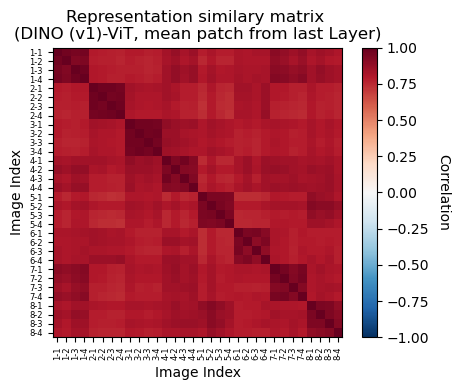

In [10]:
# use the mean patch last as the image representation to do a correlation matrix visualization
# use matplotlib only no seaborn
import matplotlib.pyplot as plt
import numpy as np
corr = np.corrcoef(mean_patch_last)
plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similary matrix \n(DINO (v1)-ViT, mean patch from last Layer)")
# show image as 1-1, 1-2 etc, as class 1, instance 1 and 2
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

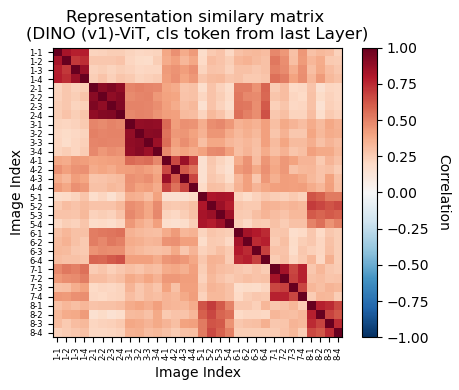

In [11]:
# check the representation of cls token
correlation_cls = np.corrcoef(cls_last)
plt.figure(figsize=(5,4))
plt.imshow(correlation_cls, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similary matrix \n(DINO (v1)-ViT, cls token from last Layer)")
# show image as 1-1, 1-2 etc, as class 1, instance 1 and 2
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.xticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=90, fontsize=6)
plt.yticks(ticks=np.arange(len(images_rgb)), labels=[f"{i+1}-{j+1}" for i in range(len(images_rgb) // 4) for j in range(4)], rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)
print("cls_tokens shape:", cls_tokens.shape)

nlayers, nimg, dim = pooled_patch_tokens.shape
print(f"Number of layers: {nlayers}, Number of images: {nimg}, Dimension: {dim}")

# for each layer, compute the correlation matrix of the pooled patch tokens across images
patch_rsm = np.zeros((nlayers, nimg, nimg))
cls_rsm = np.zeros((nlayers, nimg, nimg))
for li in range(nlayers):
    patch_rsm[li] = np.corrcoef(pooled_patch_tokens[li])
    cls_rsm[li] = np.corrcoef(cls_tokens[li])

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)
Number of layers: 13, Number of images: 32, Dimension: 768


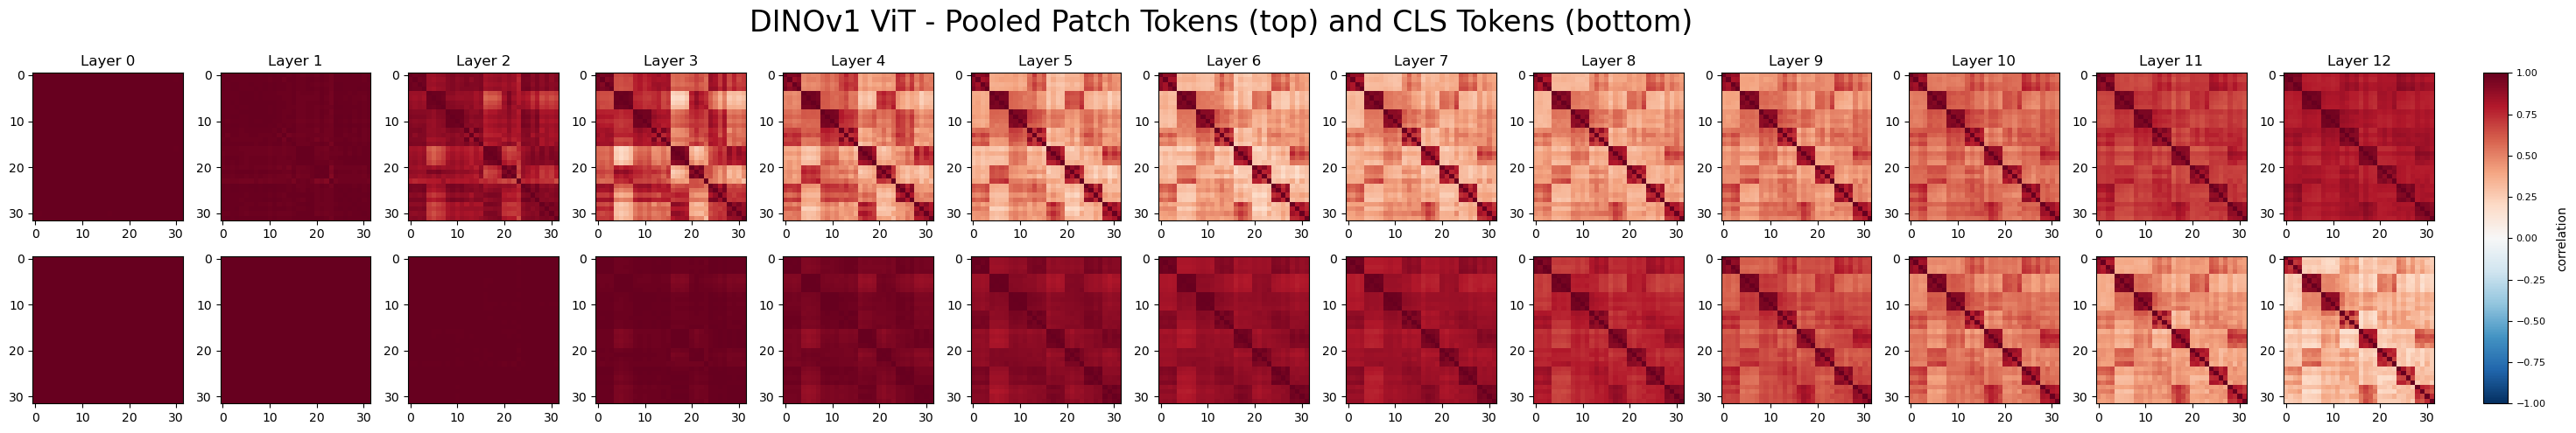

In [13]:
# visualize the rsm for each layer
nlayers = 13
fig, axes = plt.subplots(2, nlayers, figsize=(2*nlayers+2, 5))

for li in range(nlayers):
    img = axes[0, li].imshow(patch_rsm[li],
                             cmap='RdBu_r',
                             vmin=-1, vmax=1,
                             aspect='auto')
    axes[0, li].set_title(f"Layer {li}")
    
    axes[1, li].imshow(cls_rsm[li],
                       cmap='RdBu_r',
                       vmin=-1, vmax=1,
                       aspect='auto')

plt.suptitle(
    "DINOv1 ViT - Pooled Patch Tokens (top) and CLS Tokens (bottom)",
    fontsize=24
)

plt.tight_layout()

# ---- Add shared colorbar outside ----
pos = axes[0, -1].get_position()

cax = fig.add_axes([
    pos.x1 + 0.02,     # slight right shift
    axes[1, 0].get_position().y0,  # bottom of bottom row
    0.01,             # width
    axes[0, 0].get_position().y1 - axes[1, 0].get_position().y0  # full height
])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', labelpad=8)
cbar.ax.tick_params(labelsize=8)

# save
plt.savefig("../figures/dinoV1_corr_matrix.png",
            dpi=300,
            bbox_inches='tight')

plt.show()